# Python coding skills for statistics Part 2

This Juppyter notebook contains the code examples form the blog post [Python coding skills for statistics Part 2](https://docs.google.com/document/d/1XusbfJoZ7CQxbeWPPXMM84BA-VeUn8lkPUuUy7RcW8M/edit).

I've intentionally left empty code cells throughout the notebook,
which you can use to try some Python commands on your own.
For example,
you can copy-paste some of the commands in previous cells,
modify them and run to see what happens.
Try to break things.

**To run a code cell, press** the play button in the menu bar, or use the keyboard shortcut **SHIFT+ENTER**.

### Notebook setup

In [1]:
# %pip install ministats

In [2]:
# Figures setup
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    style="whitegrid",
    rc={'figure.figsize': (5, 3)},
)
# High-resolution figures please
%config InlineBackend.figure_format = 'retina'

def savefig(fig, filename):
    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight", pad_inches=0)

<Figure size 640x480 with 0 Axes>

## Introduction

### Context

### Example dataset: IQ scores

Consider the following dataset,
which consists of IQ scores of students who took a smart drug.

In [3]:
iqs = [ 95.7, 100.1,  95.3, 100.7, 123.5, 119.4,  84.4, 109.6,
       108.7,  84.7, 111.0,  92.1, 138.4, 105.2,  97.5, 115.9,
       104.4, 105.6, 104.8, 110.8,  93.8, 106.6,  71.3, 130.6,
       125.7, 130.2, 101.2, 109.0, 103.8,  96.7]

In [4]:
len(iqs)

30

### Descriptive statistics

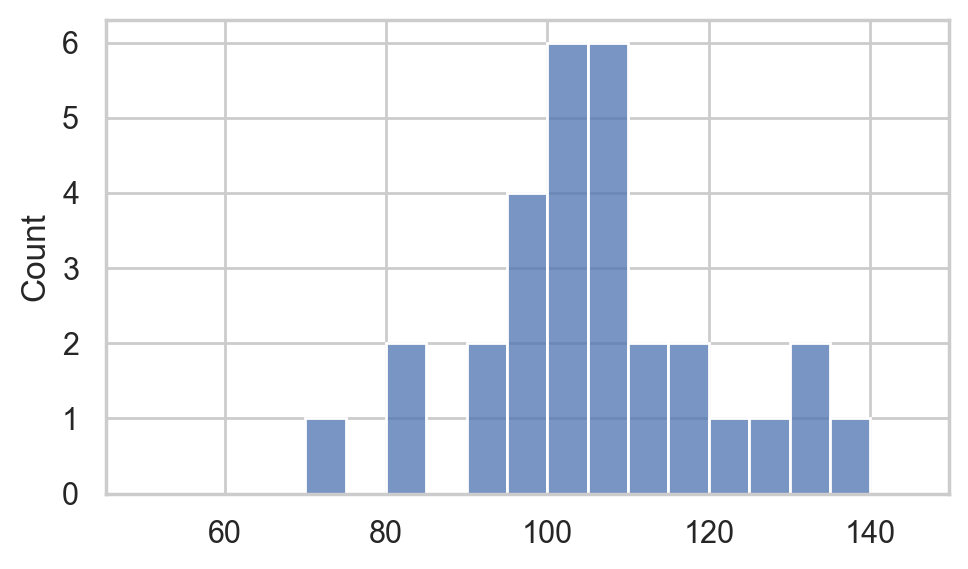

In [5]:
import seaborn as sns
sns.histplot(iqs, bins=range(50,150,5));

savefig(plt.gcf(), "figures/histplot_iqs.png")

In [6]:
from statistics import mean
mean(iqs)

105.89

In [7]:
from statistics import stdev as std
std(iqs)

14.658229417469641

### Statistical inference by eyeball

Move the sliders to choose the model parameters that best match the data.

In [8]:
import numpy as np
from scipy.stats import norm
from ipywidgets import interact

def plot_pop_and_sample(mu, sigma):
    # 1. Plot histogram of sample
    ax = sns.histplot(x=iqs, stat="density", bins=range(50,150,5), label="data")
    # 2. Plot probability density function of population model
    rvX = norm(mu, sigma)
    xs = np.linspace(50, 150, 1000)
    fXs = rvX.pdf(xs)
    sns.lineplot(x=xs, y=fXs, ax=ax, c="C0", label="model")
    print(f"current population model guess: X ~ N(mu={mu}, sigma={sigma})")

interact(plot_pop_and_sample, mu=(50,150,1), sigma=(3,40,1));

interactive(children=(IntSlider(value=100, description='mu', max=150, min=50), IntSlider(value=21, description…

## Understanding probability distributions

A random variable ...

described by



### Building computer models for probability distributions

The standard normal distribution is denoted $Z \sim \mathcal{N}(\mu=0,\sigma=1)$,
where $Z$ is the name has the probability density function:

$$
    f_Z(z) = \tfrac{1}{\sqrt{2\pi}} e^{ - \frac{1}{2}z^2}.
$$

The standard normal is a special case of the general normal $\mathcal{N}(\mu, \sigma)$
where $\mu$ is the mean and $\sigma$ is the standard deviation.


We can use one of the pre-defined probability model families in the SciPy library.
To create a computer model for the standard normal random variable $Z \sim \mathcal{N}(\mu=0, \sigma=1)$,
we need to "import" the `norm` model family form `scipy.stats` then call `norm(0,1)`
to initialize the model with parameters $\mu=0$ and $\sigma=1$.

In [9]:
from scipy.stats import norm
rvZ = norm(loc=0, scale=1)
# rvZ

The probability density function $f_Z$ is available as the `.pdf` method on the model `rvZ`.

In [10]:
rvZ.pdf(1)

0.24197072451914337

### Probability model visualizations

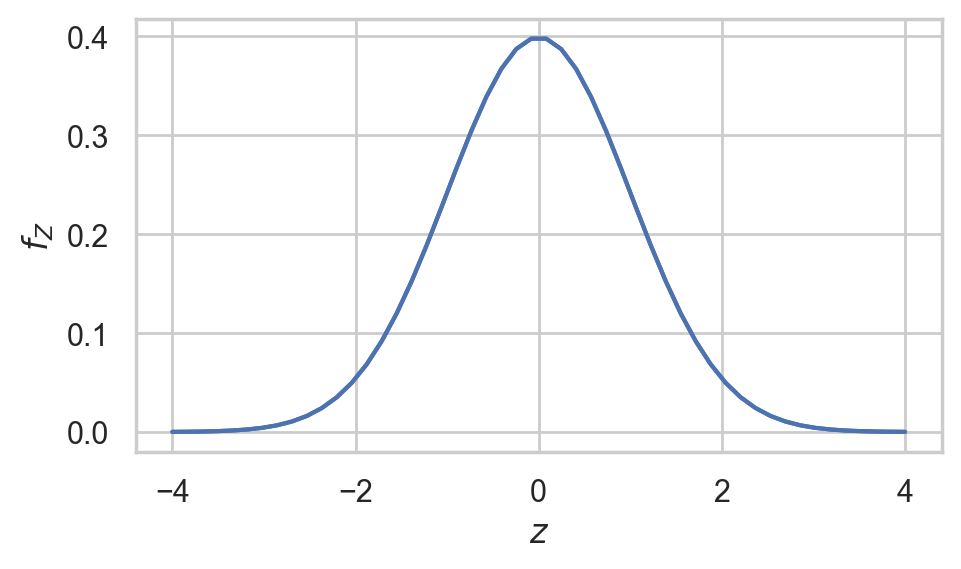

In [11]:
import numpy as np
zs = np.linspace(-4, 4)
fZs = rvZ.pdf(zs)
sns.lineplot(x=zs, y=fZs)

# FIGURES ONLY
ax = sns.lineplot(x=zs, y=fZs, color="b")
ax.set_xlabel("$z$")
ax.set_ylabel("$f_Z$")
savefig(ax.figure, "figures/pdf_of_rvZ.png")

The above graph tells you everything you need to know about the random variable $Z$.
The possible values of $Z$ are concentrated around the mean $\mu=0$.
The region of highest density is roughly between $z=-1$ and $z=1$,
with most of values between $z=-2$ and $z=2$,
then the probability densities drops off to form long tails.

The above graph shows the "shape" of the normal distribution $\mathcal{N}(\mu=0, \sigma=1)$,
which is just one representative of the general normal distribution.
Here some examples of graphs of the normal distribution for choices of the parameters $\mu$ and $\sigma$
to give you an idea of what they do.

![normal_panel.png](./attachments/normal_panel.png)

There are dozens of other probability distributions that can be useful for modelling 

You can take a look at the probability distirbution graphs here

TODO links to other panels of pdfs



### Doing probability calculations

Calculating probabilities with the continuous random variable $Z$ requires using *integration*,
which the process of computing the total are under a curve for some region.
For example, 
the probability that the random variable $Z$ will have a value somewhere
between $a$ and $b$ is defined as $\textrm{Pr}(\{a \leq Z \leq b\}) = \int_{z=a}^{z=b} f_Z(z) dz$.

In words ...

In [12]:
from scipy.integrate import quad
quad(rvZ.pdf, a=1, b=2)[0]

0.13590512198327787

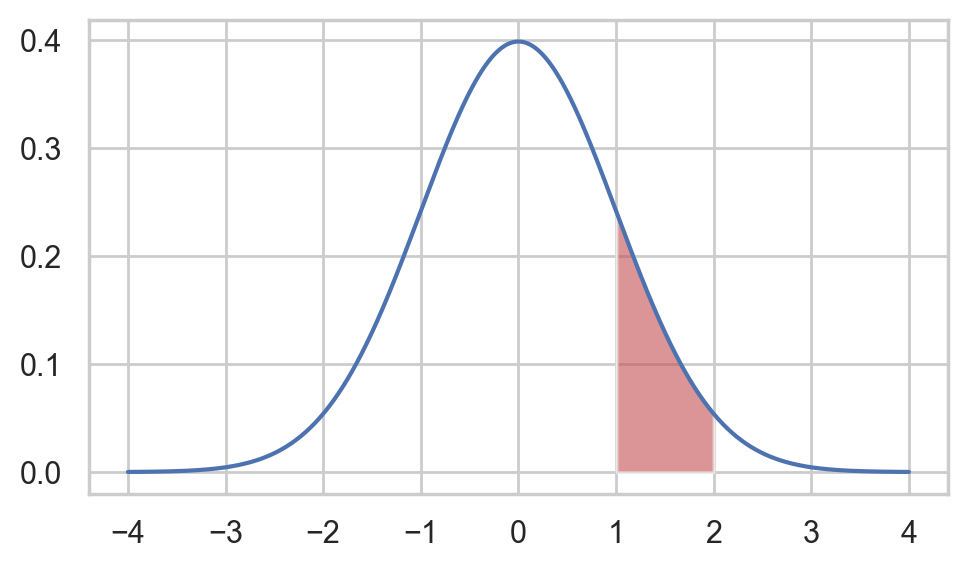

In [13]:
# FIGURES ONLY
zs = np.linspace(-4, 4, 1000)
fZs = rvZ.pdf(zs)
ax = sns.lineplot(x=zs, y=fZs)
mask = (1 < zs) & (zs < 2)
ax.fill_between(zs[mask], y1=fZs[mask], alpha=0.6, facecolor="C3")
savefig(ax.figure, "figures/pdf_of_rvZ_highlight_1_to_2.png")

### Random samples

In [14]:
np.random.seed(46)
n = 10
zs = rvZ.rvs(n)
list(zs.round(3))

[0.585, 1.231, 0.822, -0.799, 0.412, -0.176, -0.073, -0.566, -0.093, 0.857]

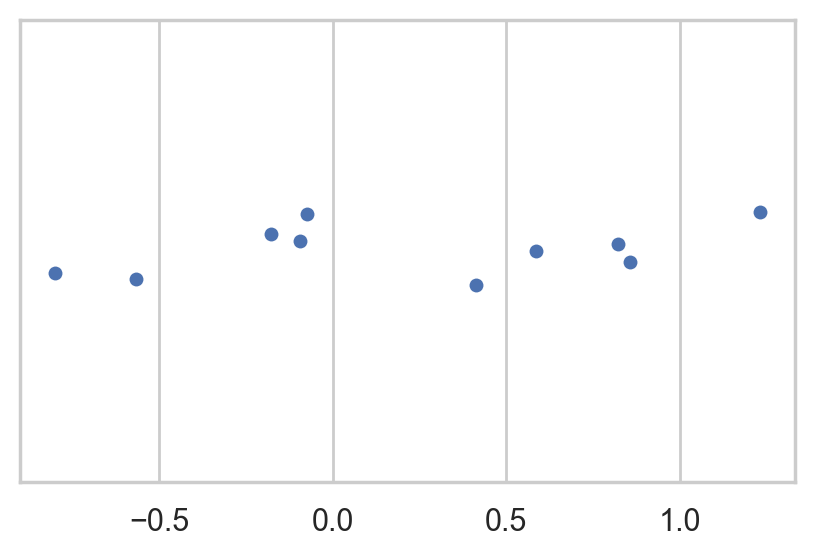

In [15]:
sns.stripplot(x=zs);

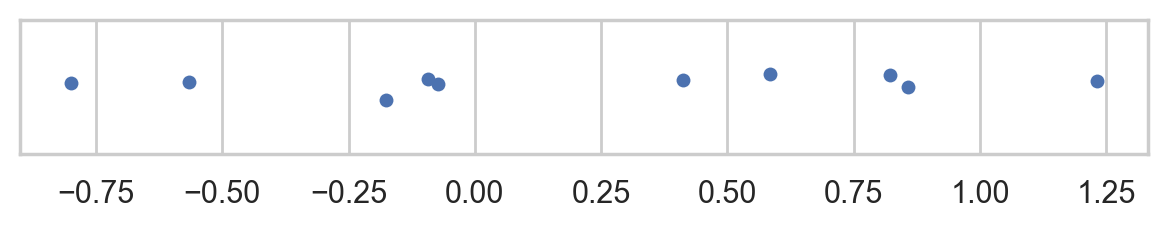

In [16]:
with plt.rc_context({"figure.figsize":(6,1.3)}):
    sns.stripplot(x=zs);
    savefig(plt.gcf(), "figures/sample_from_rvZ_n10.png")

## Understanding sampling distributions

### Probability model for the general population

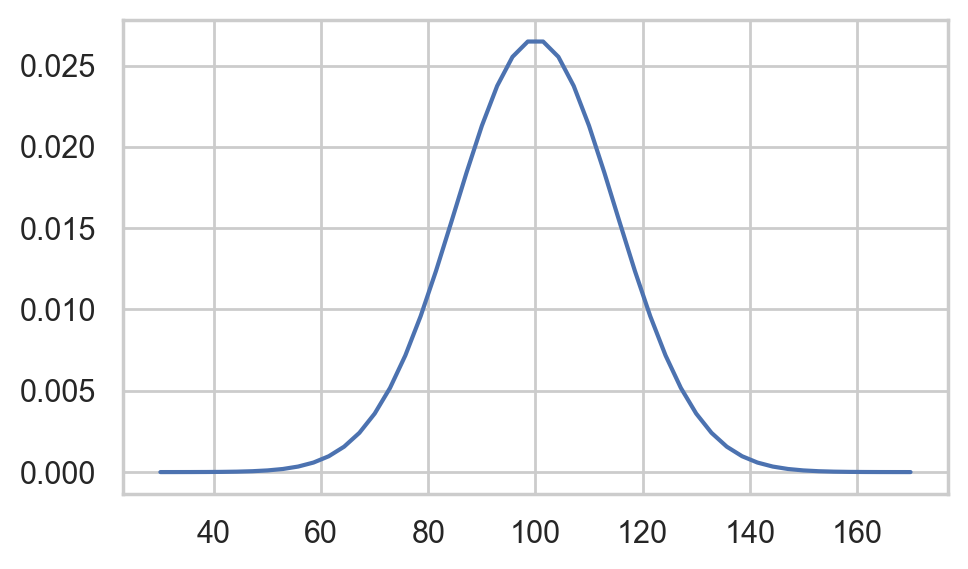

In [17]:
mu = 100
sigma = 15
rvX = norm(mu, sigma)

xs = np.linspace(30, 170)
sns.lineplot(x=xs, y=rvX.pdf(xs));


savefig(plt.gcf(), "figures/samples_from_rvX_n30.png")

In [18]:
# # FIGURES ONLY
# xs = np.linspace(30, 170)
# ax = sns.lineplot(x=xs, y=rvX.pdf(xs));
# ax.set_xlabel("$x$")
# ax.set_ylabel("$f_{X}$");
# savefig(plt.gcf(), "figures/pdf_plot_of_N10015.png")

### Random samples from the population

The *sampling distribution* of the mean for samples
of size $n=30$ from the distribution $X^0 \sim \mathcal{N}(100,15)$
is denoted $\overline{\mathbf{X}^0} = \mathbf{Mean}(\mathbf{Z})$,
where $\mathbf{Z} = (Z_1, Z_2, \ldots, Z_{20})$ is a *random sample*.

The random variable $\overline{\mathbf{Z}}$ describes the kind of means we can expect to observe if
we compute the mean for a sample of size $n=20$ from the standard normal.

Let's generate $N=10$ samples $\mathbf{z}_1, \mathbf{z}_2, \mathbf{z}_3, \ldots, \mathbf{z}_{10}$ of size $n=20$
from $Z \sim \mathcal{N}(0,1)$, and compute the mean in each sample.

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


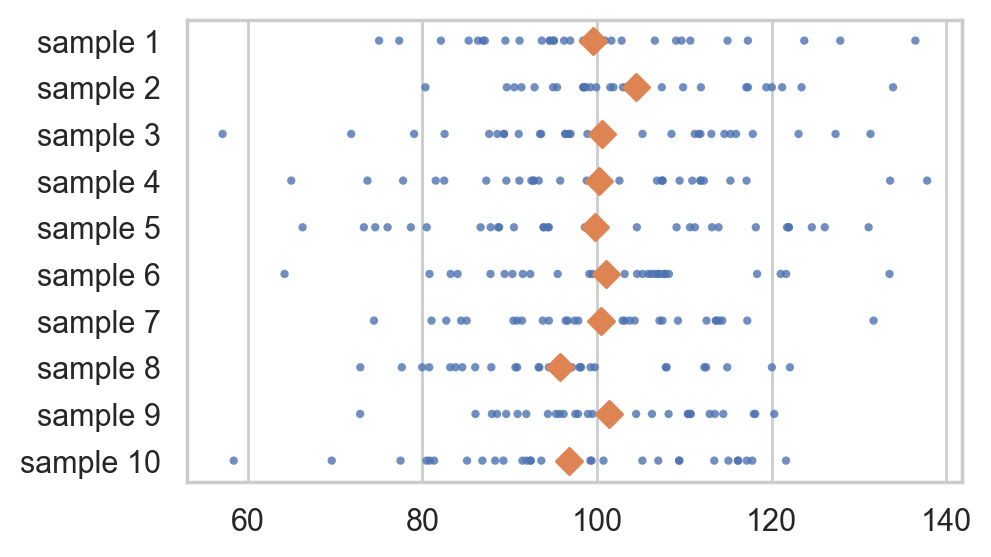

In [19]:
from ministats import gen_samples, plot_samples

np.random.seed(5)
xsamples = gen_samples(rvX, n=30, N=10)
plot_samples(xsamples);

In [20]:
# # FIGURES ONLY
# with plt.rc_context({"figure.figsize":(8,2.8)}):
#     np.random.seed(45)
#     x0samples = gen_samples(rvX, n=30, N=10)
#     plot_samples(xsamples)
#     savefig(plt.gcf(), "figures/samples_from_rvX_n30.png")

The diamond markers indicate the position of the sample means computed from each sample:
$[\overline{\mathbf{z}}_1, \overline{\mathbf{z}}_2, \overline{\mathbf{z}}_3, \ldots, \overline{\mathbf{z}}_{10}]$.

Now imagine we generate 9990 more samples to obtain a total of $N=10000$ samples from the population model:
$\mathbf{z}_1, \mathbf{z}_2, \mathbf{z}_3, \ldots, \mathbf{z}_{1000}$.
We can visualize the sampling distribution of the mean $\overline{\mathbf{Z}} = \texttt{mean}(\mathbf{Z})$
by plotting a histogram of the means computed from the $10000$ random samples,
`zbars` = $[\overline{\mathbf{z}}_1, \overline{\mathbf{z}}_2, \overline{\mathbf{z}}_3, \ldots, \overline{\mathbf{z}}_{1000}]$,
where $\overline{\mathbf{z}}_j$ denotes the sample mean computed from the data in the $j$th sample,
$\overline{\mathbf{z}}_j = \texttt{mean}(\mathbf{z}_j)$.

In [21]:
N = 1000
n = 30
xbars = []
for i in range(0, N):
    sample = rvX.rvs(n)
    xbar = mean(sample)
    xbars.append(xbar)

# xbars[0:5]

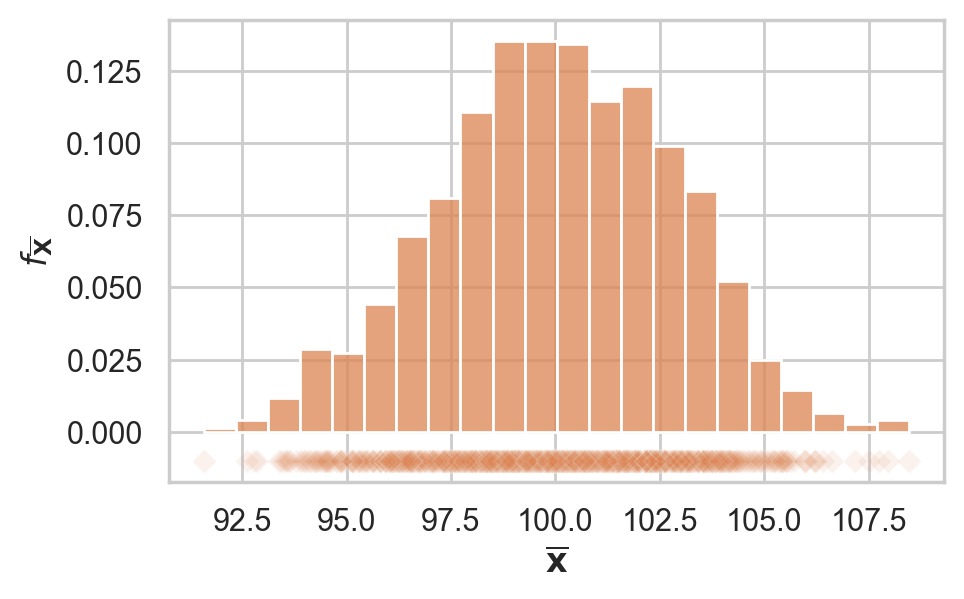

In [22]:
ax = sns.histplot(xbars, color="C1", stat="density")
sns.scatterplot(x=xbars, y=-0.01, color="C1", marker="D", alpha=0.1, ax=ax)
ax.set_xlabel("$\\overline{\\mathbf{x}}$")
ax.set_ylabel("$f_{\\overline{\\mathbf{X}}}$");

In [23]:
# # FIGURES ONLY
# with plt.rc_context({"figure.figsize":(6,2)}):
#     ax = sns.histplot(xbars, color="C1", stat="density")
#     sns.scatterplot(x=xbars, y=-0.01, color="C1", marker="D", alpha=0.1, ax=ax)
#     ax.set_ylabel("$f_{\\overline{\\mathbf{X}}}$")
#     savefig(plt.gcf(), "figures/hist_sampling_dist_mean_rvX_n30.png")

The above figure shows the sampling distribution of the mean for samples of size $n=20$ from the standard normal.
The histogram shows the "density of diamond shapes,"
and provides a representation of the sampling distribution of the mean $\overline{\mathbf{Z}} = \tt{mean}(\mathbf{Z})$.

### Central limit theorem

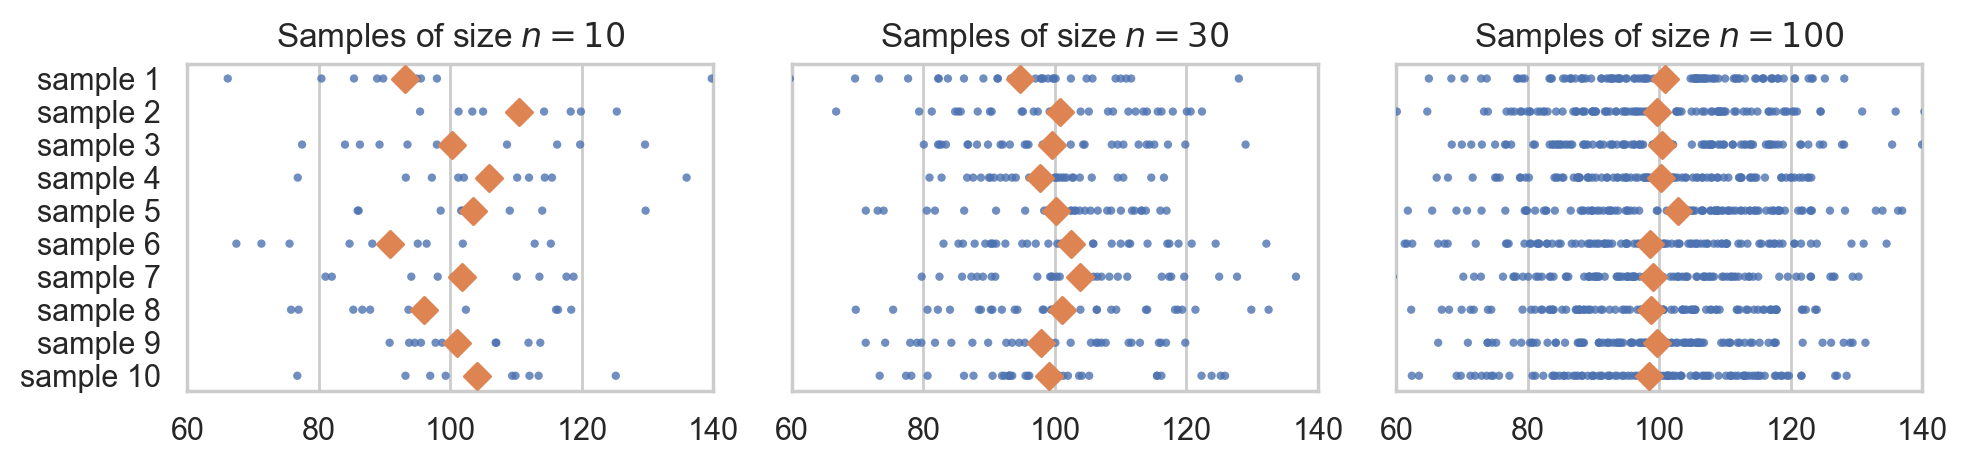

In [24]:
from ministats import plot_samples_panel
plot_samples_panel(rvX, xlims=[60,140])

savefig(plt.gcf(), "figures/samples_from_N10015_n10_n30_n100.png")

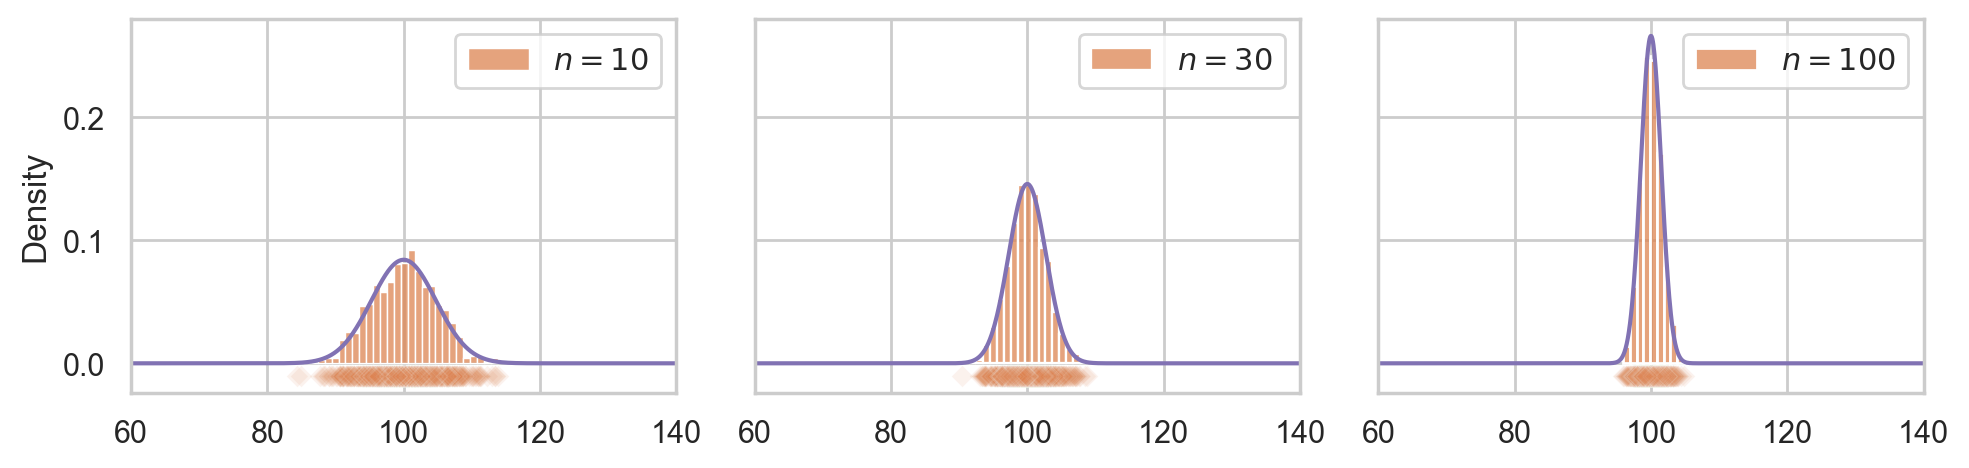

In [25]:
from ministats import plot_sampling_dists_panel
np.random.seed(47)
xbarss = plot_sampling_dists_panel(rvX, xlims=[60,140], binwidth=1)
xbars10, xbars30, xbars100 = xbarss

savefig(plt.gcf(), "figures/sampling_dist_of_N10015_n10_n30_n100.png")

In [26]:
np.std(xbars10), np.std(xbars30), np.std(xbars100)

(4.693065778983853, 2.6993483140203294, 1.4960249513626684)

Let's compare these observations from the simulation,
to the theoretical standard deviations predicted by the CLT.

In [27]:
from math import sqrt
sigma/sqrt(10), sigma/sqrt(30), sigma/sqrt(100)

(4.743416490252569, 2.7386127875258306, 1.5)

## Resampling methods

Clever techniques that reuse data from observed sample to simulate the variability in the population.


### Hypothesis testing using simulation

In [28]:
N = 10000
n = 30
xbars = []
for i in range(0, N):
    sample = rvX.rvs(n)
    xbar = mean(sample)
    xbars.append(xbar)

In [29]:
obsmean = mean(iqs)
obsmean

105.89

In [30]:
tail = [xbar for xbar in xbars if xbar > obsmean]
pvalue = len(tail) / len(xbars)
pvalue

0.0175

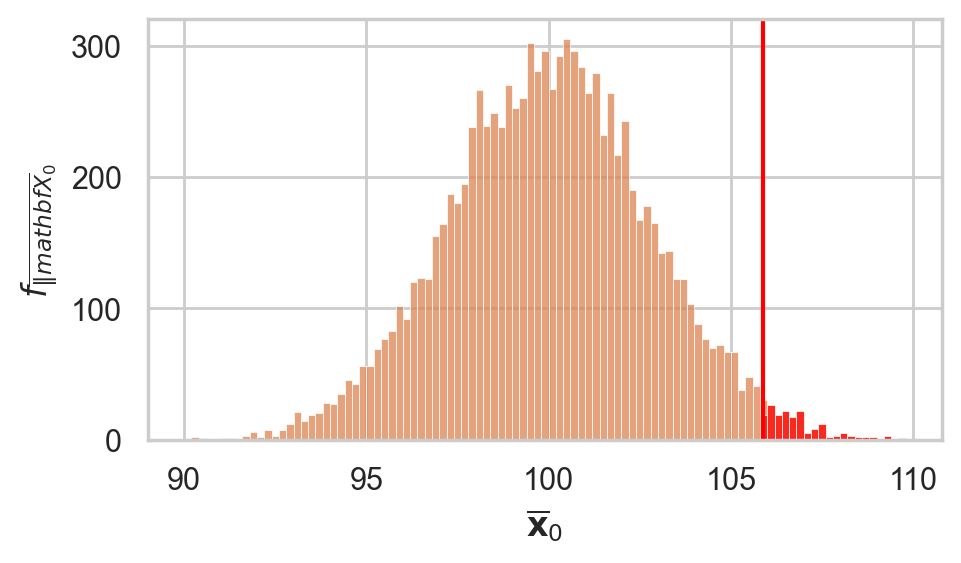

In [31]:
# plot the sampling distribution in blue
bins = np.arange(90, 110, 0.2)
ax = sns.histplot(xbars, bins=bins, color="C1")

# plot red line for the observed statistic
plt.axvline(obsmean, color="red")

# plot the values that are equal or more extreme in red
sns.histplot(tail, ax=ax, bins=bins, color="red")
_ = ax.set_ylabel("$f_{\\overline{\\|mathbf{X}}_0}$")
_ = ax.set_xlabel("$\\overline{\\mathbf{x}}_0$")

# figures only
savefig(plt.gcf(), "figures/pvalue_viz_simulation_test_iqs.png")

#### Alternative using formula

In [32]:
from ministats import ttest_mean
ttest_mean(iqs, mu0=100, alt="greater")

0.01792942680682752

### Bootstrap estimation

Generate 5000 bootstrap samples (sampling with replacement) from the sample `pricesW`.
Use the bootstrap samples to approximate the sampling distribution of the mean.

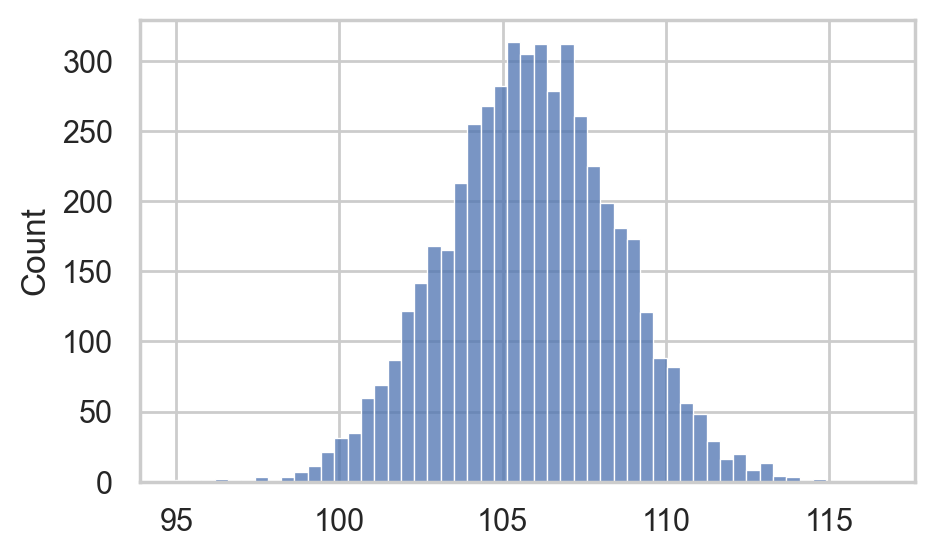

In [33]:
np.random.seed(46)

n = len(iqs)
B = 5000

bmeans = []
for i in range(0, B):
    bsample = np.random.choice(iqs, n, replace=True)
    bmean = mean(bsample)
    bmeans.append(bmean)

sns.histplot(bmeans);

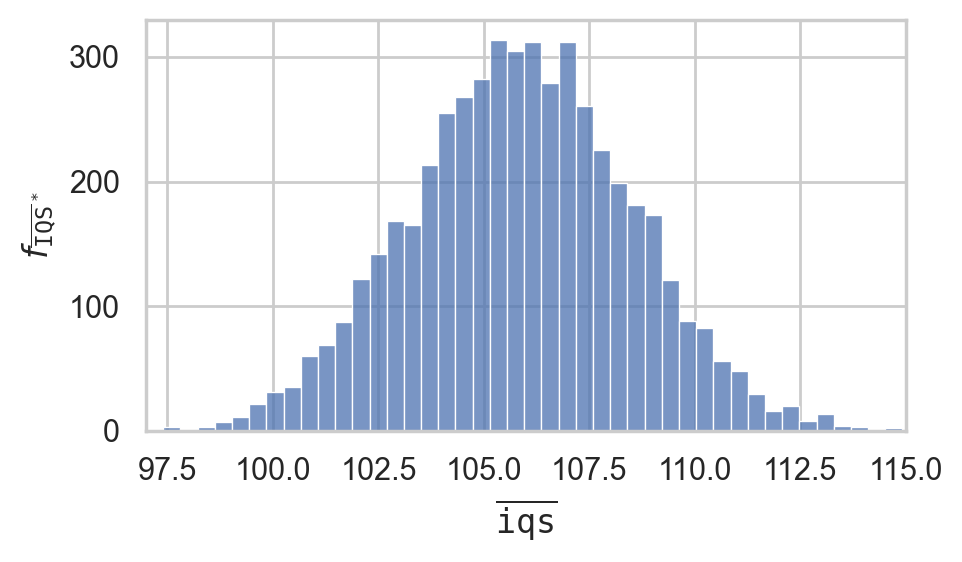

In [34]:
# FIGURES ONLY
ax = sns.histplot(bmeans)
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs.png")

In [35]:
ci90 = np.percentile(bmeans, [5, 95])
ci90

array([101.51616667, 110.1635    ])

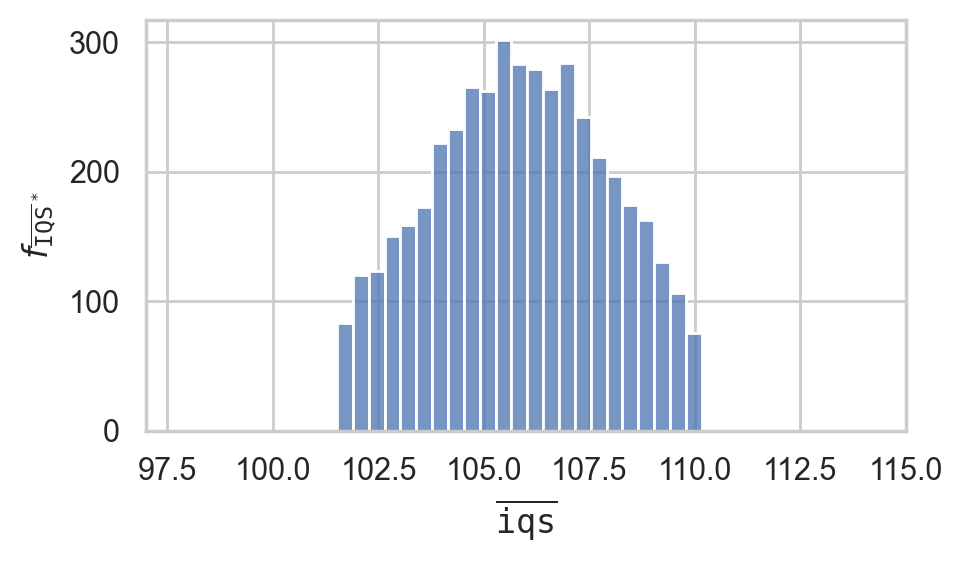

In [36]:
# FIGURES ONLY
bulk = [x for x in bmeans if x > ci90[0] and x < ci90[1]]
ax = sns.histplot(bulk)
ax.set_xlim(97,115)
ax.set_ylabel("$f_{\\overline{\\tt{IQS}}^*}$")
ax.set_xlabel("$\\overline{\\tt{iqs}}$")

savefig(plt.gcf(), "figures/bootstrap_dist_mean_iqs_ci.png")

#### Alternative using formula

In [37]:
from ministats import ci_mean
ci_mean(iqs, alpha=0.1)

[101.34277195122348, 110.43722804877652]

### Permutation test

In [38]:
# data

treated = [92.69, 117.15, 124.79, 100.57, 104.27, 121.56, 104.18,
           122.43, 98.85, 104.26, 118.56, 138.98, 101.33, 118.57, 
           123.37, 105.9, 121.75, 123.26, 118.58, 80.03, 121.15, 
           122.06, 112.31, 108.67, 75.44, 110.27, 115.25, 125.57,
           114.57, 98.09, 91.15, 112.52, 100.12, 115.2, 95.32, 
           121.37, 100.09, 113.8, 101.73, 124.9, 87.83, 106.22, 
           99.97, 107.51, 83.99, 98.03, 71.91, 109.99, 90.83, 105.48]

controls = [85.1, 84.05, 90.43, 115.92, 97.64, 116.41, 68.88, 110.51, 
            125.12, 94.04, 134.86, 85.0, 91.61, 69.95, 94.51, 81.16, 
            130.61, 108.93, 123.38, 127.69, 83.36, 76.97, 124.87, 86.36, 
            105.71, 93.01, 101.58, 93.58, 106.51, 91.67, 112.93, 88.74, 
            114.05, 80.32, 92.91, 85.34, 104.01, 91.47, 109.2, 104.04, 
            86.1, 91.52, 98.5, 94.62, 101.27, 107.41, 100.68, 114.94, 
            88.8, 121.8]


To compare the two groups,
we'll subtract the average score computed from each group.

In [39]:
def dmeans(xsample, ysample):
    dhat = np.mean(xsample) - np.mean(ysample)
    return dhat

# Calculate the observed difference between means
dscore = dmeans(treated, controls)
dscore

7.886999999999986

We'll now use the `10000` permutations of the original data
to obtain sampling distribution of the difference between means under the null hypothesis.

In [40]:
np.random.seed(43)

pdhats = []
for i in range(0, 10000):
    alliqs = np.concatenate((treated, controls))
    palliqs = np.random.permutation(alliqs)
    ptreated = palliqs[0:len(treated)]
    pcontrols = palliqs[len(treated):]
    pdhat = dmeans(ptreated, pcontrols)
    pdhats.append(pdhat)

Compute the p-value of the observed difference between means `dprice` under the null hypothesis.

In [41]:
tails = [d for d in pdhats if abs(d) > dscore]
pvalue = len(tails) / len(pdhats)
pvalue

0.0101

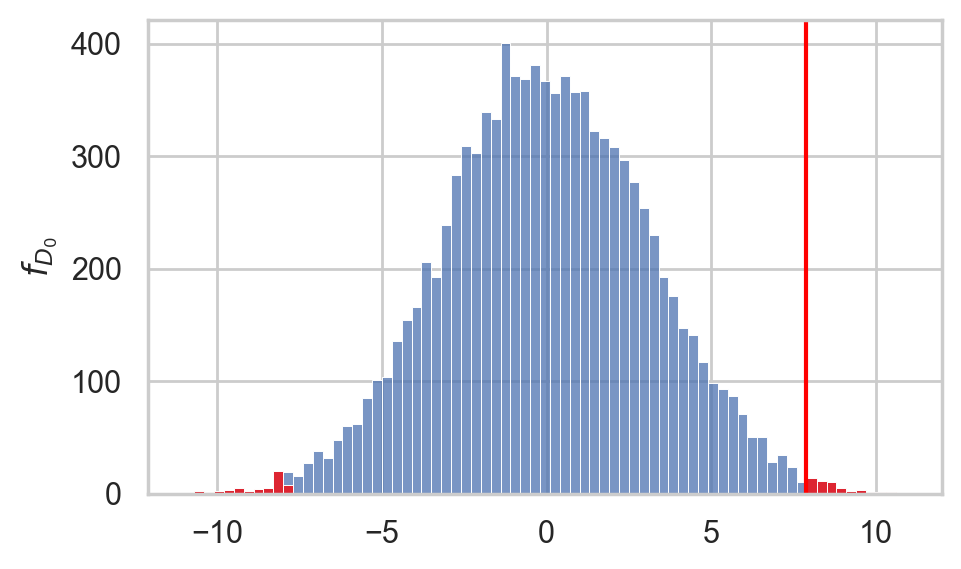

In [42]:
bins = np.arange(-11, 11, 0.3)

# plot the sampling distribution in blue
ax = sns.histplot(pdhats, bins=bins)

# plot red line for the observed statistic
plt.axvline(dscore, color="red")

# plot the values that are equal or more extreme in red
sns.histplot(tails, ax=ax, bins=bins, color="red")
_ = ax.set_ylabel("$f_{D_0}$")

savefig(plt.gcf(), "figures/pvalue_viz_permutation_test_iqs.png")

#### Alternative using formula

In [43]:
from ministats import ttest_dmeans
ttest_dmeans(treated, controls)

0.010163611652137501

## Links

- [Python tutorial](https://nobsstats.com/tutorials/python_tutorial.html)
- Previous blog posts:
  - [Outline of the stats curriculum research](https://minireference.com/blog/fixing-the-introductory-statistics-curriculum/)
  - [Book proposal](https://minireference.com/blog/no-bullshit-guide-to-statistics-progress-update/)
  - [Stats survey results](https://minireference.com/blog/what-stats-do-people-want-to-learn/)
- Book website [noBSstats.com](https://nobsstats.com/intro.html): contains all the notebooks, demos, and visualizations from the book.
- [Statistics for Hackers](https://www.youtube.com/watch?v=Iq9DzN6mvYA) talk by Jake Vanderplas
- [There's Only One Test](https://www.youtube.com/watch?v=S41zQEshs5k) talk by Allen B. Downey

<!-- 
- [Detailed book outline](https://docs.google.com/document/d/1fwep23-95U-w1QMPU31nOvUnUXE2X3s_Dbk5JuLlKAY/edit): continuously updated list of the topics that are covered in each section.
- [Pandas tutorial](https://nobsstats.com/tutorials/pandas_tutorial.html)
- [Seaborn tutorial](https://nobsstats.com/tutorials/seaborn_tutorial.html)
-->


In [44]:
x = 5

2 < x < 7

True